# Statistics and Probability Basics
**Summer of Science 2026 — CS03: Artificial Intelligence and Machine Learning**  
**Mohit Khyalia | IIT Bombay**

---

## Project Overview

Mean, median, mode, variance, standard deviation, covariance, correlation, basic probability, conditional probability, Bayes' theorem, and the normal distribution.

### Main goals:

- Compute and compare mean, median, and mode on skewed vs symmetric data.
- Compute variance, standard deviation, covariance, and correlation.
- Work through conditional probability and Bayes' theorem with a concrete example.
- Visualise the normal distribution and check the empirical rule.

---

## Setup and Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams.update({'figure.facecolor': 'white', 'axes.facecolor': 'white',
                     'axes.spines.top': False, 'axes.spines.right': False})

## Mean, Median, Mode

In [2]:
np.random.seed(1)
symmetric = np.random.normal(50, 10, 500)
skewed = np.random.exponential(20, 500)

for name, data in [('symmetric', symmetric), ('skewed', skewed)]:
    mean = np.mean(data)
    median = np.median(data)
    mode = stats.mode(np.round(data), keepdims=True).mode[0]
    print(f'{name:10s}  mean={mean:7.2f}  median={median:7.2f}  mode={mode:7.2f}')

symmetric   mean=  50.53  median=  50.39  mode=  48.00
skewed      mean=  19.59  median=  13.82  mode=   1.00


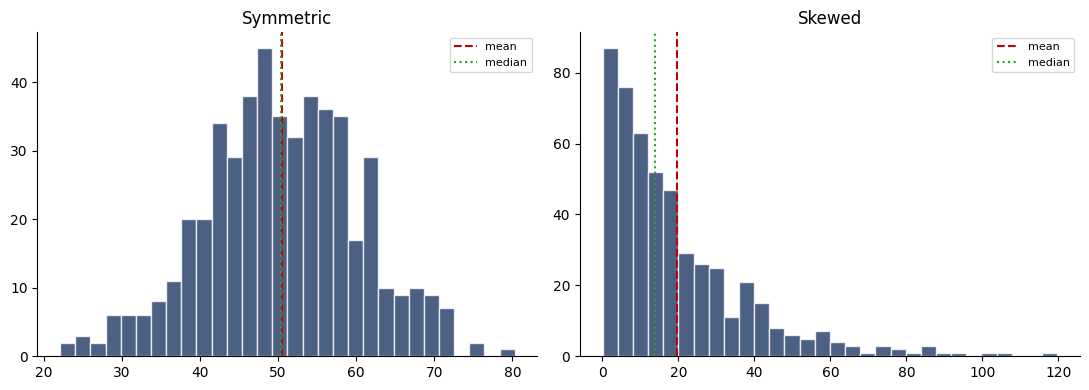

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (name, data) in zip(axes, [('Symmetric', symmetric), ('Skewed', skewed)]):
    ax.hist(data, bins=30, color='#1F3864', alpha=0.8, edgecolor='white')
    ax.axvline(np.mean(data), color='#C00000', linestyle='--', label='mean')
    ax.axvline(np.median(data), color='#2CA02C', linestyle=':', label='median')
    ax.set_title(name)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

**Observation:**
Mean and median nearly coincide for symmetric data, but diverge for skewed data — mean gets pulled toward the long tail. Same pattern used in Week 2 to decide between mean and median imputation.

## Variance and Standard Deviation

In [4]:
x = np.array([4, 8, 6, 5, 3, 7])

manual_var = sum((xi - np.mean(x))**2 for xi in x) / len(x)
manual_std = np.sqrt(manual_var)

print('Manual variance:', manual_var)
print('np.var:', np.var(x))
print('Manual std:', manual_std)
print('np.std:', np.std(x))

Manual variance: 2.9166666666666665
np.var: 2.9166666666666665
Manual std: 1.707825127659933
np.std: 1.707825127659933


In [5]:
print('np.var (population, ddof=0):', np.var(x, ddof=0))
print('np.var (sample, ddof=1):    ', np.var(x, ddof=1))
print('pandas .var() default:      ', pd.Series(x).var())

np.var (population, ddof=0): 2.9166666666666665
np.var (sample, ddof=1):     3.5
pandas .var() default:       3.5


**Observation:**
NumPy defaults to population variance (`ddof=0`), pandas defaults to sample variance (`ddof=1`) — same data, different default, same source of confusion as `StandardScaler` verification in Week 2.

## Covariance and Correlation

In [6]:
np.random.seed(2)
study_hours = np.random.uniform(1, 10, 100)
exam_score = 5 * study_hours + np.random.normal(0, 8, 100) + 30
unrelated = np.random.uniform(0, 100, 100)

cov_matrix = np.cov(study_hours, exam_score)
corr_matrix = np.corrcoef(study_hours, exam_score)

print('Covariance(study_hours, exam_score):', round(cov_matrix[0,1], 2))
print('Correlation(study_hours, exam_score):', round(corr_matrix[0,1], 4))
print('Correlation(study_hours, unrelated):', round(np.corrcoef(study_hours, unrelated)[0,1], 4))

Covariance(study_hours, exam_score): 32.98
Correlation(study_hours, exam_score): 0.8384
Correlation(study_hours, unrelated): -0.1723


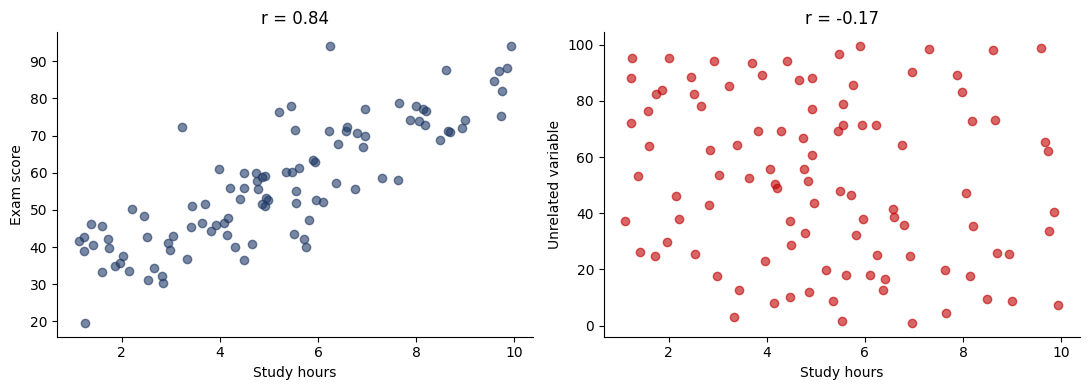

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(study_hours, exam_score, alpha=0.6, color='#1F3864')
axes[0].set_xlabel('Study hours')
axes[0].set_ylabel('Exam score')
axes[0].set_title(f'r = {corr_matrix[0,1]:.2f}')

axes[1].scatter(study_hours, unrelated, alpha=0.6, color='#C00000')
axes[1].set_xlabel('Study hours')
axes[1].set_ylabel('Unrelated variable')
axes[1].set_title(f'r = {np.corrcoef(study_hours, unrelated)[0,1]:.2f}')
plt.tight_layout()
plt.show()

**Observation:**
Covariance has units (depends on the scale of both variables) and is hard to interpret directly. Correlation is covariance normalised by both standard deviations, always between -1 and 1, which is why `sns.heatmap(df.corr())` in Week 2 used correlation rather than raw covariance.

## Basic Probability

In [8]:
np.random.seed(3)
rolls = np.random.randint(1, 7, 10000)

p_six = np.mean(rolls == 6)
p_even = np.mean(rolls % 2 == 0)

print(f'P(roll=6) over 10000 simulated rolls: {p_six:.4f}  (theoretical: {1/6:.4f})')
print(f'P(even) over 10000 simulated rolls:   {p_even:.4f}  (theoretical: {0.5:.4f})')

P(roll=6) over 10000 simulated rolls: 0.1653  (theoretical: 0.1667)
P(even) over 10000 simulated rolls:   0.4995  (theoretical: 0.5000)


## Conditional Probability and Bayes' Theorem

Disease test example: disease prevalence 1%, test sensitivity 95% (true positive rate), false positive rate 5%.

$$P(\text{Disease} \mid \text{Positive}) = \frac{P(\text{Positive} \mid \text{Disease}) \, P(\text{Disease})}{P(\text{Positive})}$$

In [9]:
p_disease = 0.01
p_positive_given_disease = 0.95
p_positive_given_no_disease = 0.05

p_no_disease = 1 - p_disease
p_positive = (p_positive_given_disease * p_disease) + (p_positive_given_no_disease * p_no_disease)

p_disease_given_positive = (p_positive_given_disease * p_disease) / p_positive

print(f'P(Positive): {p_positive:.4f}')
print(f'P(Disease | Positive): {p_disease_given_positive:.4f}')

P(Positive): 0.0590
P(Disease | Positive): 0.1610


In [10]:
np.random.seed(4)
n_people = 200000
has_disease = np.random.binomial(1, p_disease, n_people)

test_positive = np.where(
    has_disease == 1,
    np.random.binomial(1, p_positive_given_disease, n_people),
    np.random.binomial(1, p_positive_given_no_disease, n_people)
)

simulated = has_disease[test_positive == 1].mean()
print(f'Simulated P(Disease | Positive): {simulated:.4f}')
print(f'Bayes formula result:            {p_disease_given_positive:.4f}')

Simulated P(Disease | Positive): 0.1633
Bayes formula result:            0.1610


**Observation:**
Despite 95% sensitivity, a positive test only means about a 16% chance of actually having the disease, because the disease is rare (1%) and false positives from the other 99% accumulate. The simulation confirms the formula. This is the same reasoning behind why a high Recall alone (Week 2's imbalanced dataset notebook) doesn't tell the full story — base rates matter.

## Normal Distribution

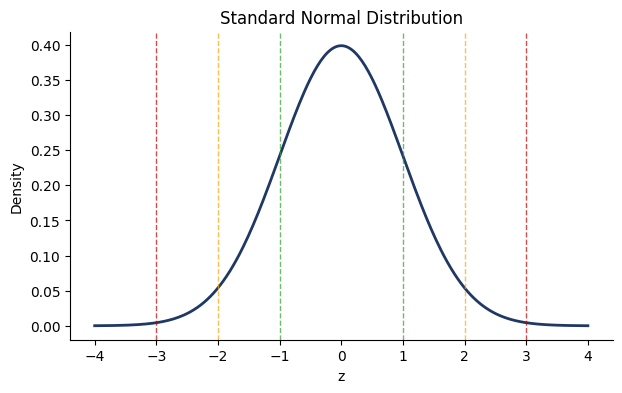

In [11]:
mu, sigma = 0, 1
z = np.linspace(-4, 4, 300)
pdf = stats.norm.pdf(z, mu, sigma)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(z, pdf, color='#1F3864', lw=2)

for k, color in [(1, '#2CA02C'), (2, '#FFA500'), (3, '#C00000')]:
    ax.axvline(k, color=color, linestyle='--', lw=1, alpha=0.7)
    ax.axvline(-k, color=color, linestyle='--', lw=1, alpha=0.7)

ax.set_xlabel('z')
ax.set_ylabel('Density')
ax.set_title('Standard Normal Distribution')
plt.show()

In [12]:
np.random.seed(5)
sample = np.random.normal(0, 1, 100000)

for k in [1, 2, 3]:
    within = np.mean(np.abs(sample) <= k)
    print(f'P(|z| <= {k}): {within:.4f}')

P(|z| <= 1): 0.6814
P(|z| <= 2): 0.9543
P(|z| <= 3): 0.9974


**Observation:**
Matches the empirical rule: roughly 68% within 1 std, 95% within 2 std, 99.7% within 3 std. This is the standard deviation appearing again — same quantity computed in the variance section above and used directly in `StandardScaler`'s formula from Week 2.